In [2]:
import numpy as np

import json
from matplotlib import pyplot as plt 
from pathlib import Path

import pandas as pd

In [34]:
# DATA_DIR = Path("../../tmp/toy-experiments-5k")
# " 2023-05-s6/dev/toy-experiments-prca-reconreg"
DATA_DIR = Path("../../artifacts/2023-05-s6/dev/toy-experiments-prca-reconreg-seeds")

In [35]:
def load_auroc(eps, seeds, subset_slug, basis_name, model="mlp32", layer="act2"):
    
    merged_key = "auroc"
    
    
    merged_stat = dict()
    
    arr_aurocs = []
    arr_area_aurocs = []
    arr_teacher_aurocs = []
    
    for six, seed in enumerate(seeds):
        
        file = DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / model / f"subdataset--{subset_slug}" / layer / basis_name / "auroc.json"


        with open(file, "r") as fh:
            _stat = json.load(fh)
                        
        ks = np.array(_stat["ks"])
        if six == 0:
            merged_stat["ks"] = ks
        else:
            assert (merged_stat["ks"] == ks).all()
        
        auroc = np.array(_stat["auroc"])
        auroc = np.where(auroc < 0.5, 1-auroc, auroc)
        
        
        assert ks[0] == 0
        
        # ks = [0, 1, ..., d]
        # auroc: shape = (num ks,)
        area_auroc_varying_k = np.trapz(
            auroc,
            dx=1/ks[-1]
        )
        
        
        arr_aurocs.append(auroc)
        arr_area_aurocs.append(area_auroc_varying_k)
        arr_teacher_aurocs.append(auroc[-1])
        
    # shape: (num_seeds, len(ks))
    arr_aurocs = np.vstack(arr_aurocs)
    
    nseeds = len(seeds)
    assert arr_aurocs.shape[0] ==  nseeds
    
    merged_stat["mean_auroc"] = np.mean(arr_aurocs, axis=0)
    merged_stat["stderr_auroc"] = np.std(arr_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat["mean_area_auroc"] = np.mean(arr_area_aurocs, axis=0)
    merged_stat["stderr_area_auroc"] = np.std(arr_area_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat['mean_teacher_auroc'] = np.mean(arr_teacher_aurocs)
    merged_stat['std_teacher_auroc'] = np.std(arr_teacher_aurocs) / (nseeds ** 0.5)

    return merged_stat

    
load_auroc(eps=0.1, seeds=range(1, 1+1), subset_slug="2vs3", model="mlp64", basis_name="pca--centered")

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 'mean_auroc': array([0.5       , 0.87517092, 0.95845182, 0.95851473, 0.95832179,
        0.95837633, 0.95893835, 0.95913548, 0.95939133, 0.95932842,
        0.95934939, 0.95940811, 0.95913968, 0.95908515, 0.95911451,
        0.95910193, 0.95910193, 0.95908516, 0.95907677, 0.95911032,
        0.95907257, 0.95908516, 0.95907676, 0.95906837, 0.95907677,
        0.95907257, 0.95906837, 0.95907676, 0.95907676, 0.95907676,
        0.95907676, 0.95907676]),
 'stderr_auroc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'mean_area_auroc': 0.9489215517476679,
 'stderr_area_auroc': 0.0,
 'mean_teacher_auroc': 0.9590767621994019,
 'std_teacher_auroc': 0.0}

In [36]:
from matplotlib import cm

cm.Blues(0)

(0.9686274509803922, 0.984313725490196, 1.0, 1.0)

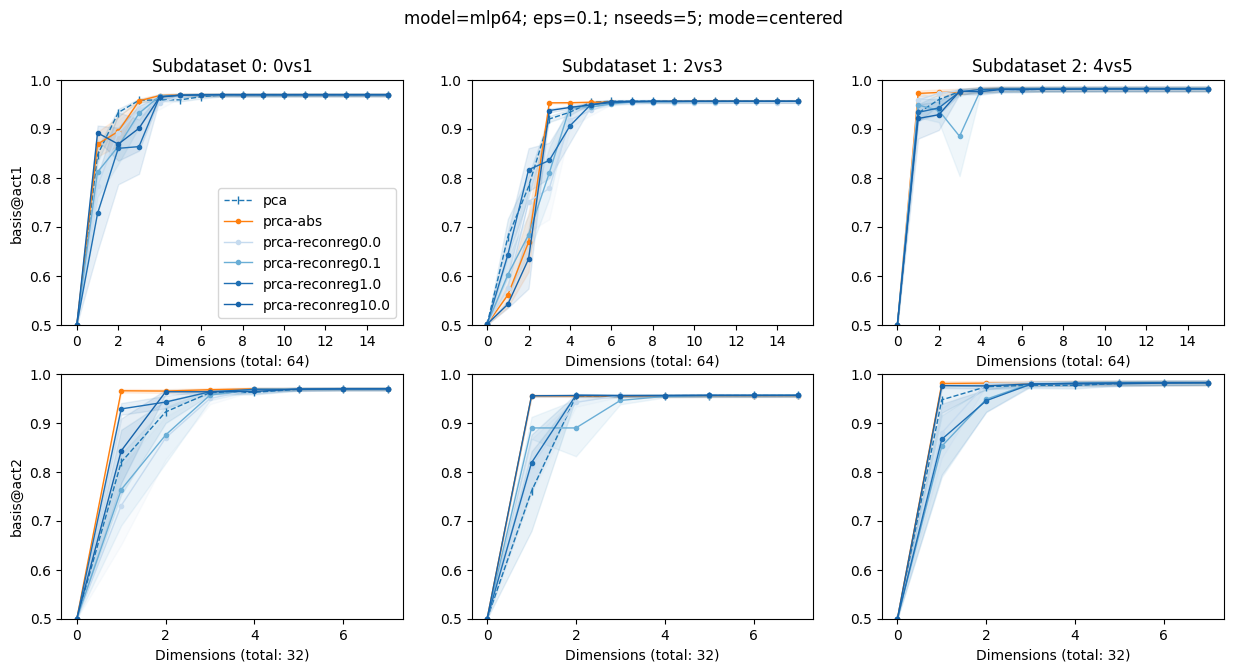

In [40]:
import matplotlib as mpl

def color(name):
#     if "pca" in name:
#         return "black"
    if "prca-recon" in name:
        beta = name.split("reg")[-1]
        color_norm = dict(zip(
            ["0.0", "0.1", "1.0", "10.0"],
            [0.25, 0.5, 0.75, 0.8]
        ))
        return cm.Blues(color_norm[beta])
    else:
        return None
    
def ls(name):
    if "pca" in name:
        return "--"
    else:
        return None
    
def viz_auroc(
    model="mlp64", eps=1.0, 
    seeds=[1], 
    layers=["act1", "act2"],
    basis_names = [
        "pca", 
        "prca-abs", 
#         "prca-recon",
        "prca-reconreg0.0",
#         "prca-reconreg0.01",
        "prca-reconreg0.1",
        "prca-reconreg1.0",
        "prca-reconreg10.0",
#         "prca",
#         "random1", "random2", "random3",
    ],
    mode="centered"
):
    
    
    nrows = len(layers)
    ncols = 3
    plt.figure(figsize=(ncols*5, nrows*3.5))
    plt.suptitle(f"model={model}; eps={eps}; nseeds={len(seeds)}; mode={mode}")
    
    for lix, layer in enumerate(layers):
        
        
        for pix, slug in enumerate([
            "0vs1",
            "2vs3",
            "4vs5"
        ]):
            plt.subplot(nrows, ncols, lix*ncols + pix + 1)
            
            for basis in basis_names:
                basis_name = f"{basis}--{mode}"
                
                stats = load_auroc(eps=eps, seeds=seeds, subset_slug=slug, model=model, layer=layer, basis_name=basis_name)
                
                dims = len(stats['ks'])
                top_k = dims // 4
                ks = stats['ks'][:top_k]
                mean = stats['mean_auroc'][:top_k]
                std = stats['stderr_auroc'][:top_k] 
                plt.plot(
                    ks, mean, 
                    label=basis, 
                    lw=1,
                    color=color(basis),
                    ls=ls(basis),
                    marker="|" if "pca" in basis else "."
                )
                
                plt.fill_between(
                    ks,
                    mean - std,
                    mean + std, 
                    alpha=0.1,
                    color=plt.gca().lines[-1].get_color()
                )
                
            plt.xlabel(f"Dimensions (total: {dims})")
            plt.xticks(ks[::2])
            plt.ylim([0.5, 1])
            if pix == 0:
                plt.ylabel(f"basis@{layer}")

            if lix == 0:
                plt.title(f"Subdataset {pix}: {slug}")
                
            if lix == 0 and pix == 0:
                plt.legend()
                
viz_auroc(seeds=range(1, 5+1), eps=0.1)

In [44]:
def table(model, eps, mode="centered"):
    arr_layers = ["act1", "act2"]
    arr_groups = ["0vs1", "2vs3", "4vs5"]
    seeds = list(range(1, 5+1))
    arr_bases = [
        "pca", 
        "prca-abs", 
        "prca-reconreg0.0",
        "prca-reconreg0.1",
        "prca-reconreg1.0",
        "prca-reconreg10.0",
    ]
    
    
    arr_rows = []
    
    print(f"                 model={model}; eps={eps}; mode={mode}")
    
    for lix, layer in enumerate(arr_layers):
        
        for basis in arr_bases:
            
            row = dict(layer=layer, basis=basis)
        
        
            for slug in arr_groups:
                data = load_auroc(
                    eps=eps,
                    seeds=seeds,
                    subset_slug=slug,
                    model=model,
                    layer=layer,
                    basis_name=f"{basis}--{mode}"
                )
                
                
                
                row[slug] = "%.4f±%.4f" % (data["mean_area_auroc"], data["stderr_area_auroc"])
        
            arr_rows.append(row)
        
    
    return pd.DataFrame(arr_rows)

        
table(model="mlp64", eps=0.1)

                 model=mlp64; eps=0.1; mode=centered


,layer,basis,0vs1,2vs3,4vs5
0,act1,pca,0.9624±0.0029,0.9442±0.0022,0.9762±0.0047
1,act1,prca-abs,0.9625±0.0032,0.9413±0.0027,0.9771±0.0047
2,act1,prca-reconreg0.0,0.9606±0.0037,0.9382±0.0039,0.9763±0.0049
3,act1,prca-reconreg0.1,0.9607±0.0035,0.9395±0.0025,0.9746±0.0049
4,act1,prca-reconreg1.0,0.9582±0.0037,0.9422±0.0026,0.9760±0.0047
5,act1,prca-reconreg10.0,0.9615±0.0035,0.9400±0.0028,0.9755±0.0045
6,act2,pca,0.9548±0.0043,0.9421±0.0016,0.9719±0.0045
7,act2,prca-abs,0.9613±0.0029,0.9483±0.0024,0.9735±0.0046
8,act2,prca-reconreg0.0,0.9498±0.0056,0.9433±0.0017,0.9705±0.0040
9,act2,prca-reconreg0.1,0.9515±0.0051,0.9438±0.0020,0.9684±0.0047
